### Import bibliotek i konfiguracja

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

ADOPTION_SPEED_LABELS = {
    0: '0–7',
    1: '8–30',
    2: '31–90',
    3: '>100',
}
CLASS_ORDER = sorted(ADOPTION_SPEED_LABELS.keys())
CLASS_NAMES = [ADOPTION_SPEED_LABELS[c] for c in CLASS_ORDER]

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Wczytanie i przygotowanie danych

In [2]:
PROCESSED_DIR = '../data/processed'
MODELS_DIR = Path('../models')
INPUT_PATH = f'{PROCESSED_DIR}/train_clean_anomaly.csv'

df = pd.read_csv(INPUT_PATH)

if 'is_anomaly' in df.columns:
    df = df.drop(columns=['is_anomaly'])

y = df['AdoptionSpeed']
X = df.drop(columns=['AdoptionSpeed'])
feature_names = X.columns.tolist()

print('Rozkład klas AdoptionSpeed:')
class_dist = pd.DataFrame({
    'liczba': y.value_counts().sort_index(),
    'procent': (y.value_counts(normalize=True).sort_index() * 100).round(2),
})
class_dist.index.name = 'AdoptionSpeed'
display(class_dist)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Skalowanie
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nX_train: {X_train_scaled.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test_scaled.shape}, y_test:  {y_test.shape}')

Rozkład klas AdoptionSpeed:


,liczba,procent
AdoptionSpeed,,
0,3474,23.40
1,3993,26.90
2,3209,21.62
3,4168,28.08



X_train: (11875, 20), y_train: (11875,)
X_test:  (2969, 20), y_test:  (2969,)


### Bazowa sieć neuronowa

/mnt/c/Users/Natalia/Desktop/g/pet_adoption_ml/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Classification report (base MLP)
              precision    recall  f1-score   support

         0–7       0.35      0.35      0.35       695
        8–30       0.34      0.37      0.35       798
       31–90       0.33      0.19      0.24       642
        >100       0.47      0.58      0.52       834

    accuracy                           0.38      2969
   macro avg       0.37      0.37      0.36      2969
weighted avg       0.37      0.38      0.37      2969

Accuracy: 0.3843
F1 macro: 0.3644


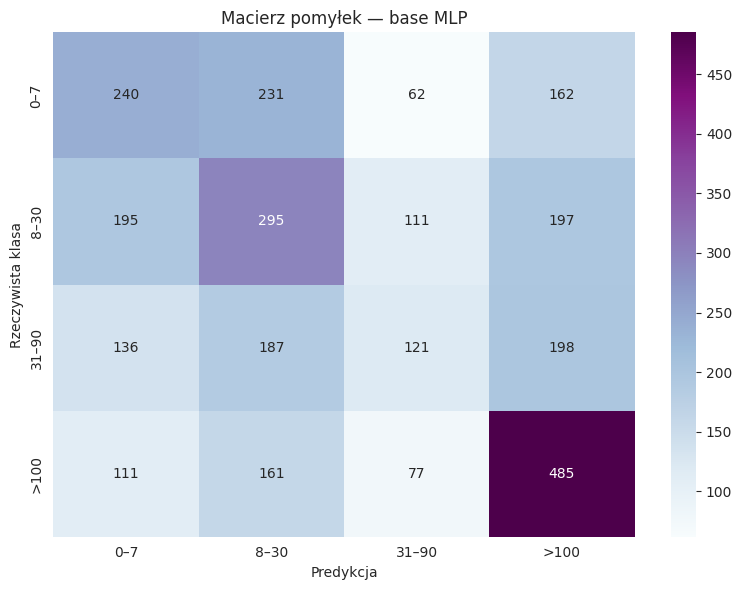

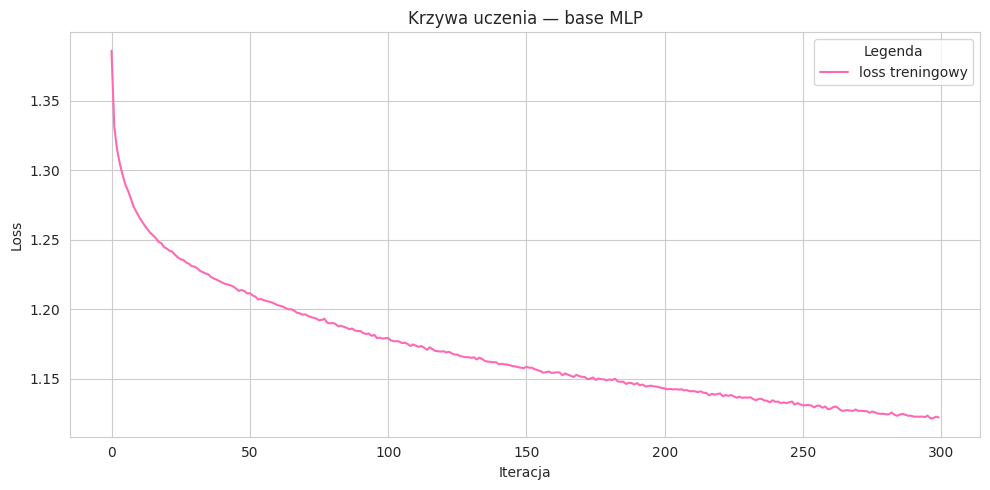

In [3]:
nn_base = MLPClassifier(random_state=RANDOM_STATE, max_iter=300)
nn_base.fit(X_train_scaled, y_train)

y_pred_base = nn_base.predict(X_test_scaled)

acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base, average='macro')

print('Classification report (base MLP)')
print(classification_report(y_test, y_pred_base, target_names=CLASS_NAMES))
print(f'Accuracy: {acc_base:.4f}')
print(f'F1 macro: {f1_base:.4f}')

cm_base = confusion_matrix(y_test, y_pred_base, labels=CLASS_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='BuPu',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Macierz pomyłek — base MLP')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.show()

# Krzywa uczenia
plt.figure(figsize=(10, 5))
plt.plot(nn_base.loss_curve_, color='hotpink', label='loss treningowy')
plt.title('Krzywa uczenia — base MLP')
plt.xlabel('Iteracja')
plt.ylabel('Loss')
plt.legend(title='Legenda')
plt.tight_layout()
plt.show()

### Cross-validation

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    MLPClassifier(random_state=RANDOM_STATE, max_iter=300),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='accuracy',
)

print('Wyniki accuracy dla poszczególnych powtórzeń:')
for i, score in enumerate(cv_scores, start=1):
    print(f'  Powtórzenie {i}: {score:.4f}')

print(f'\nŚrednia: {cv_scores.mean():.4f}')
print(f'Odchylenie std: {cv_scores.std():.4f}')
print(f'Zakres (średnia ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

/mnt/c/Users/Natalia/Desktop/g/pet_adoption_ml/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/c/Users/Natalia/Desktop/g/pet_adoption_ml/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/c/Users/Natalia/Desktop/g/pet_adoption_ml/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/c/Users/Natalia/Desktop/g/pet_adoption_ml/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum itera

Wyniki accuracy dla poszczególnych powtórzeń:
  Powtórzenie 1: 0.3848
  Powtórzenie 2: 0.3840
  Powtórzenie 3: 0.3663
  Powtórzenie 4: 0.3726
  Powtórzenie 5: 0.3773

Średnia: 0.3770
Odchylenie std: 0.0070
Zakres (średnia ± std): 0.3770 ± 0.0070


/mnt/c/Users/Natalia/Desktop/g/pet_adoption_ml/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


### Kalibracja

/mnt/c/Users/Natalia/Desktop/g/pet_adoption_ml/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/c/Users/Natalia/Desktop/g/pet_adoption_ml/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/c/Users/Natalia/Desktop/g/pet_adoption_ml/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/c/Users/Natalia/Desktop/g/pet_adoption_ml/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum itera

Najlepsze parametry:
{'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}

Najlepszy wynik CV (accuracy): 0.3898

Porównanie na zbiorze testowym:


,accuracy,f1_macro
base,0.384304,0.364352
po GridSearchCV,0.401482,0.378435


Classification report (po kalibracji)
              precision    recall  f1-score   support

         0–7       0.41      0.38      0.39       695
        8–30       0.35      0.34      0.35       798
       31–90       0.31      0.19      0.24       642
        >100       0.47      0.64      0.54       834

    accuracy                           0.40      2969
   macro avg       0.38      0.39      0.38      2969
weighted avg       0.39      0.40      0.39      2969



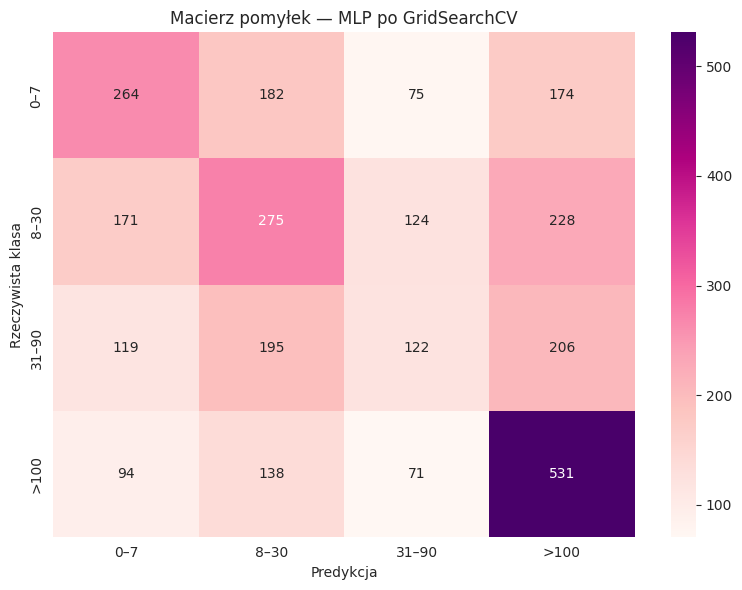

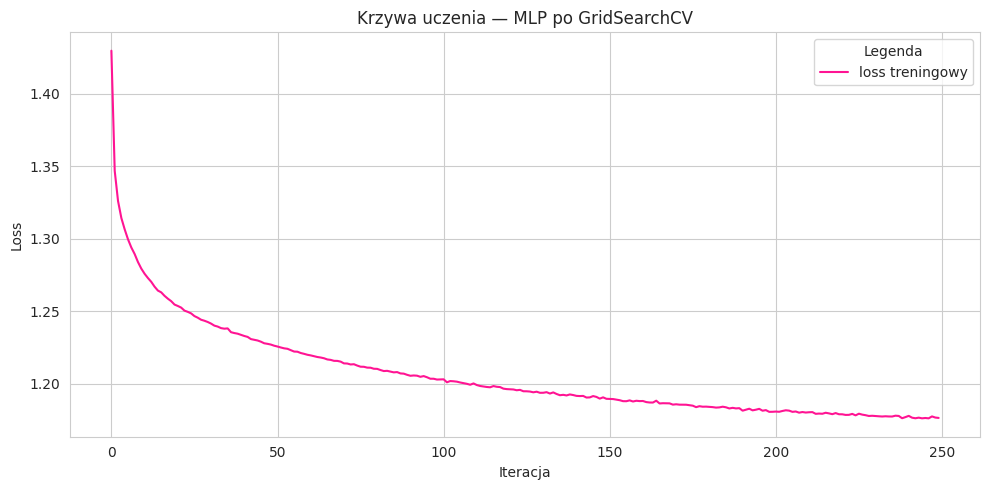

In [5]:
param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 64), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01],
}

grid_search = GridSearchCV(
    estimator=MLPClassifier(random_state=RANDOM_STATE, max_iter=300),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

grid_search.fit(X_train_scaled, y_train)

print('Najlepsze parametry:')
print(grid_search.best_params_)
print(f'\nNajlepszy wynik CV (accuracy): {grid_search.best_score_:.4f}')

nn_best = grid_search.best_estimator_
y_pred_tuned = nn_best.predict(X_test_scaled)

acc_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, average='macro')

comparison = pd.DataFrame({
    'accuracy': [acc_base, acc_tuned],
    'f1_macro': [f1_base, f1_tuned],
}, index=['base', 'po GridSearchCV'])

print('\nPorównanie na zbiorze testowym:')
display(comparison)

print('Classification report (po kalibracji)')
print(classification_report(y_test, y_pred_tuned, target_names=CLASS_NAMES))

cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=CLASS_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='RdPu',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Macierz pomyłek — MLP po GridSearchCV')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.show()

# Krzywa uczenia skalibrowanego modelu
plt.figure(figsize=(10, 5))
plt.plot(nn_best.loss_curve_, color='deeppink', label='loss treningowy')
plt.title('Krzywa uczenia — MLP po GridSearchCV')
plt.xlabel('Iteracja')
plt.ylabel('Loss')
plt.legend(title='Legenda')
plt.tight_layout()
plt.show()

### Zapis modelu

In [6]:
if f1_base >= f1_tuned:
    nn_final = nn_base
    wybrany_model = 'base MLP'
else:
    nn_final = nn_best
    wybrany_model = 'MLP po GridSearchCV'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(nn_final, MODELS_DIR / 'nn_best.pkl')

print(f'Zapisano model ({wybrany_model}): {MODELS_DIR / "nn_best.pkl"}')
print(f'  accuracy test: {max(acc_base, acc_tuned):.4f}, f1_macro test: {max(f1_base, f1_tuned):.4f}')

Zapisano model (MLP po GridSearchCV): ../models/nn_best.pkl
  accuracy test: 0.4015, f1_macro test: 0.3784
